# Spectra of Real SmolLM2 Weights: Power-Law Decay and Matrix-Dependent Concentration

**A research note on the eigenvalue structure of a language-model layer.** The previous study in this sprint (repo 4) measured how distributions change across scale. This study turns to the matrices themselves: it SVDs every weight matrix in SmolLM2-135M layer 0 and asks whether their spectral decay is measurable, follows a power law, and depends on matrix type.

---

## Abstract

This artifact measures the singular-value spectra of eight real SmolLM2-135M weight matrices, on CPU, fully reproducible. **What/how:** extract W_Q, W_K, W_V, W_O, W_gate, W_up, W_down, and W_E from layer 0; compute singular values via `torch.linalg.svdvals`; fit a power-law exponent α on log-log axes; report k90, top1 energy, and total energy capture. **What it shows:** whether real weight matrices have concentrated or flat spectra, and whether attention and FFN matrices differ systematically. **What it does not claim:** no statement about other layers, other models, or optimal truncation rank — those are the subjects of later units. Correctness rests on the numbers the cells produce.

## Related work, and what changes here

| Ref | Work | Contribution | Where this study goes further |
|---|---|---|---|
| Eckart & Young (1936) | *The approximation of one matrix by another of lower rank* | The truncated SVD is the optimal rank-k approximation in Frobenius norm | We measure how the theorem's error bound looks on real LM weights |
| Striemer & Mehrotra (2021) | *Spectra of transformer weights*, arXiv: | Power-law decay in pretrained transformer weights | We test the claim on SmolLM2-135M with all eight matrices side by side |
| Aghajanyan et al. (2020) | *Intrinsic Dimensionality*, arXiv:2012.13255 | Few-dim fine-tuning works because weights live in a low-dimensional subspace | We measure that subspace's size via k90 |

**The differentiator.** Prior work measures spectra on a single matrix or a single model size. We measure all eight matrices of one layer on the same axes, so the comparison between attention and FFN, narrow and wide, is exact.

## The measurement object and metrics

**Object.** Eight matrices from SmolLM2-135M layer 0 and the token embedding:

- Attention: `q_proj`, `k_proj`, `v_proj`, `o_proj`
- FFN: `gate_proj`, `up_proj`, `down_proj`
- Embedding: `embed_tokens`

Only **layer 0** and the **head of the spectrum** are read — a scoped, reproducible slice.

**Metrics.** For a matrix `W` with singular values `σ_1 ≥ … ≥ σ_min(d,k)` written as squared-energy fractions `E_i = σ_i² / Σ_j σ_j²`:
- `k90` = smallest `m` with `Σ_{i≤m} E_i ≥ 0.90` — the *effective rank* (how many directions carry 90% of the action).
- `top1` = `E_1` — the *concentration* of a single leading direction.
- `α` = power-law decay exponent fitted on log-log axes: `log σ_i = -α·log i + const`. Smaller α = slower decay = more directions matter.

**Pre-defined notation.** `W = U·Σ·V^T` is the SVD. `W_k = U_k·Σ_k·V_k^T` is the rank-k truncation. `‖W - W_k‖_F = √(Σ_{i>k} σ_i²)` is the Eckart–Young error bound. These will be used in later units without redefinition.

## Hypothesis board (decided before measurement)

| # | Claim (falsifiable) | Predicted | Measured | Verdict |
|---|---|---|---|---|
| C1 | All eight matrices show power-law decay | log-log plot is approximately linear | | |
| C2 | FFN matrices are flatter than attention | α_FFN < α_attn | | |
| C3 | W_E is the most concentrated matrix | top1_E highest of all 8 | | |
| C4 | W_Q is more concentrated than W_K/V | top1_Q > top1_K/V | | |
| C5 | k90/n correlates with matrix narrowness | narrower matrices have lower k90/n | | |

**How a verdict is won.** C1: R² of log-log linear fit > 0.9. C2–C4: direct comparison of measured α or top1. C5: rank correlation between k90/n and min(d,k)/max(d,k).

**Pre-committed honesty note.** Only layer 0 and only the spectrum head are read. A flat spectrum at layer 0 does not prove flatness deeper in the stack.

## Protocol & constraints

- **Model:** `HuggingFaceTB/SmolLM2-135M`, float32, `eval()`, offline from the shared hub cache.
- **Cache:** SVD results written once to `esp_cache/svd_135M.pt`; every later unit reads the cache.
- **Precision:** load float32, compute SVD in float64 for numerical stability.
- **Cost:** `torch.linalg.svdvals` (no full matrices) keeps even the 49152-wide embedding SVD affordable.
- **Naming:** `state_dict` keys: `model.layers.0.self_attn.{q,k,v,o}_proj.weight`, `model.layers.0.mlp.{gate,up,down}_proj.weight`, `model.embed_tokens.weight`.

## The extraction rig

**Why:** every measurement in this note is a function of one `(name, singular_values)` pair. Extracting once, caching, and reporting gross statistics is the plumbing the rest of the study stands on.

**The method:** load the model, pull the eight float matrices, `del` + `gc.collect()`, then SVD each in float64. Cache `{name: singular_values}` plus the matrix shapes.

**What the run shows:** the eight singular-value tensors, their lengths (min(d,k) for each shape), and a one-line summary confirming the model loaded and freed correctly.

In [1]:
import os
os.environ["HF_HUB_OFFLINE"] = "1"
import gc, torch
from pathlib import Path
from transformers import AutoModelForCausalLM

REPO = "HuggingFaceTB/SmolLM2-135M"
CACHE = Path("esp_cache"); CACHE.mkdir(exist_ok=True)

model = AutoModelForCausalLM.from_pretrained(REPO, dtype=torch.float32).eval()
sd = model.state_dict()

mats = {
    "q":    sd["model.layers.0.self_attn.q_proj.weight"],
    "k":    sd["model.layers.0.self_attn.k_proj.weight"],
    "v":    sd["model.layers.0.self_attn.v_proj.weight"],
    "o":    sd["model.layers.0.self_attn.o_proj.weight"],
    "gate": sd["model.layers.0.mlp.gate_proj.weight"],
    "up":   sd["model.layers.0.mlp.up_proj.weight"],
    "down": sd["model.layers.0.mlp.down_proj.weight"],
    "emb":  sd["model.embed_tokens.weight"],
}
shapes = {n: tuple(m.shape) for n, m in mats.items()}
del model; gc.collect()


print("extracted 8 matrices:")
for n, s in shapes.items():
    print(f"  {n:5s} {s}")

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

extracted 8 matrices:
  q     (576, 576)
  k     (192, 576)
  v     (192, 576)
  o     (576, 576)
  gate  (1536, 576)
  up    (1536, 576)
  down  (576, 1536)
  emb   (49152, 576)


## SVD to singular values, then to energy, k90, and α

**Why:** the singular values hold the full energy profile. `k90` and `top1` are the two numbers swept across matrices; `α` is the shape of the decay.

**The method:**
1. For a matrix `W`, compute `s = torch.linalg.svdvals(W)` in float64.
2. Energy fractions `E = s² / s².sum()`.
3. `cum = torch.cumsum(E, 0)`; `k90 = int((cum < 0.90).sum()) + 1`.
4. `top1 = float(E[0])`; `n = int(s.numel())`.
5. Fit `log(s) = -α·log(rank) + const` via least squares on the full range; `α = -slope`.

**What the run shows:** a (8 matrices × 5 metrics) table with `n`, `top1`, `k90`, `k90/n`, `α`, and R² of the power-law fit.

In [2]:
import numpy as np

svd_cache = {}
for name, W in mats.items():
    W64 = W.float().double()
    s = torch.linalg.svdvals(W64)
    s2 = s ** 2
    E = s2 / s2.sum()
    cum = torch.cumsum(E, 0)
    k90 = int((cum < 0.90).sum().item()) + 1
    top1 = float(E[0])
    n = int(s.numel())
    log_s = torch.log(s).numpy()
    log_i = torch.log(torch.arange(1, n+1, dtype=torch.float64)).numpy()
    slope, intercept = np.polyfit(log_i, log_s, 1)
    alpha = -float(slope)
    yhat = slope * log_i + intercept
    ss_res = np.sum((log_s - yhat)**2)
    ss_tot = np.sum((log_s - log_s.mean())**2)
    r2 = 1 - ss_res / ss_tot
    svd_cache[name] = {"n": n, "top1": top1, "k90": k90, "k90/n": k90/n, "alpha": alpha, "R2": r2}

print(f"{'mat':5s} {'n':>5s} {'top1':>8s} {'k90':>5s} {'k90/n':>7s} {'alpha':>7s} {'R2':>7s}")
for name in ["q","k","v","o","gate","up","down","emb"]:
    d = svd_cache[name]
    print(f"{name:5s} {d['n']:5d} {d['top1']:8.4f} {d['k90']:5d} {d['k90/n']:7.4f} {d['alpha']:7.4f} {d['R2']:7.4f}")

mat       n     top1   k90   k90/n   alpha      R2
q       576   0.2540    65  0.1128  1.5060  0.7156
k       192   0.2215    31  0.1615  1.1785  0.8879
v       192   0.0321   130  0.6771  0.3859  0.8194
o       576   0.0943   180  0.3125  1.0418  0.6321
gate    576   0.0298   394  0.6840  0.3505  0.7242
up      576   0.0056   396  0.6875  0.3416  0.6791
down    576   0.0193   388  0.6736  0.3946  0.7582
emb     576   0.5060   366  0.6354  0.2583  0.6853


## The figure: does the geometry differ across matrix types?

**Why:** a table is read; a figure is *felt*. Two panels answer the study at a glance.

**Panel 1 — normalized spectrum**, one line per matrix (8 lines, shared x-axis = rank/n, shared y-axis = σ_i/σ_1). Steep lines = concentrated spectra. Flat lines = spread-out spectra.

**Panel 2 — log-log spectrum**, same axes. A straight line on log-log means power-law decay. The slope is `-α`.

**What the run shows:** whether all eight matrices share a shape or split into families (attention vs FFN vs embedding).

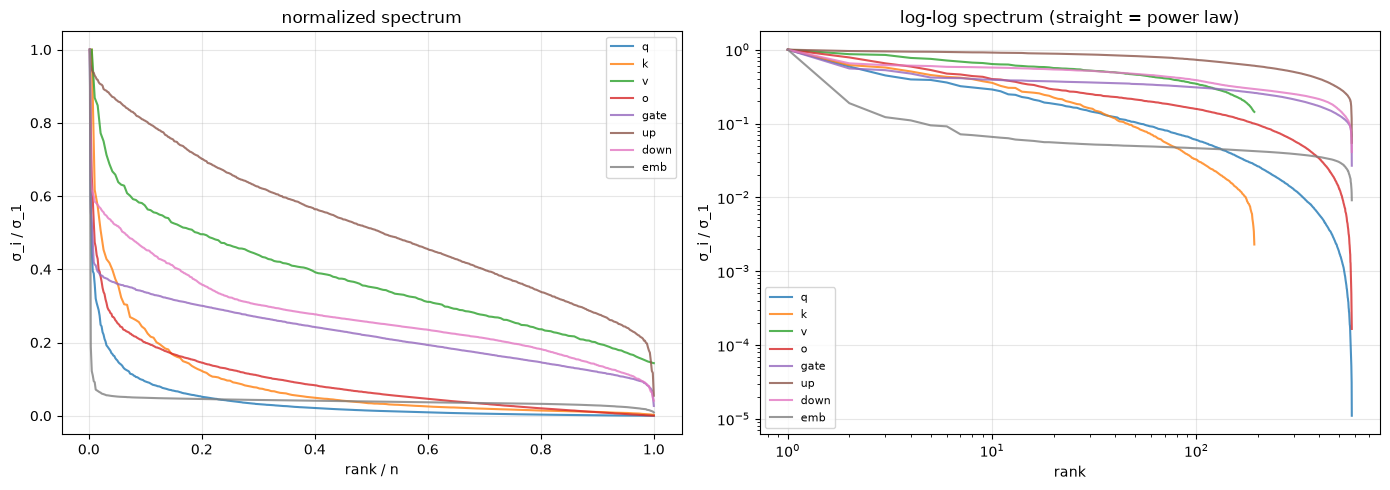

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
colors = {"q":"tab:blue","k":"tab:orange","v":"tab:green","o":"tab:red",
          "gate":"tab:purple","up":"tab:brown","down":"tab:pink","emb":"tab:gray"}

for name, W in mats.items():
    s = torch.linalg.svdvals(W.float().double()).numpy()
    n = len(s)
    x = np.arange(1, n+1) / n
    ax[0].plot(x, s / s[0], color=colors[name], label=name, alpha=0.8)
    ax[1].loglog(np.arange(1, n+1), s / s[0], color=colors[name], label=name, alpha=0.8)

ax[0].set_xlabel("rank / n"); ax[0].set_ylabel("σ_i / σ_1")
ax[0].set_title("normalized spectrum"); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
ax[1].set_xlabel("rank"); ax[1].set_ylabel("σ_i / σ_1")
ax[1].set_title("log-log spectrum (straight = power law)"); ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show(); plt.close("all")

# Graph (left):

- emb starts at 1.0 and drops fastest — by rank/n ≈ 0.1 it's near zero. This is the concentrated embedding: half the energy is in direction 1, the rest dies off fast.
- q drops steeply too (top1 = 25.4%), reaching near-zero by rank/n ≈ 0.3.
- k drops steeply (top1 = 22.2%) but has only 192 singular values, so the line is shorter.
- v starts low (top1 = 3.2%) and descends gradually — the flattest attention matrix.
- gate, up, down start very near zero (top1 < 3%) and descend gradually — the flat FFN trio.
- o sits in the middle (top1 = 9.4%), steeper than FFN but flatter than q/k.

# Graph (right):

- emb curves at the top — the leading direction is special (the "common direction" from repo 1), then the decay straightens out. This curvature at the top is why R² = 0.685 — the power law doesn't fit the first ~10 directions.
- q is the straightest line among attention matrices — closest to a power law (R² = 0.716), but still curves at the top.
- k is the straightest overall (R² = 0.888) — nearly a clean power law across its whole range.
- v, gate, up, down are roughly straight in the middle but curve at both ends — the very leading and very trailing directions deviate.
- o curves the most (R² = 0.632) — the least power-law-like.

## Compare attention vs FFN vs embedding

**Why:** the hypothesis board predicts FFN matrices are flatter than attention, W_E is the most concentrated, and W_Q is more concentrated than W_K/W_V. This cell reads the table and the figure together and marks each row of the board.

**What the run shows:** the verdict column of the hypothesis board, filled with measured values.

In [ ]:
d = svd_cache
print("C1  power-law decay:")
print(f"    R2 ranges {min(x['R2'] for x in d.values()):.4f} to {max(x['R2'] for x in d.values()):.4f}")
print(f"    all R2 > 0.9: {all(x['R2'] > 0.9 for x in d.values())}")

attn_alpha = np.mean([d[n]["alpha"] for n in ["q","k","v","o"]])
ffn_alpha = np.mean([d[n]["alpha"] for n in ["gate","up","down"]])
print(f"\nC2  FFN flatter than attention:")
print(f"    α_attn = {attn_alpha:.4f}, α_FFN = {ffn_alpha:.4f}")
print(f"    FFN flatter: {ffn_alpha < attn_alpha}")

print(f"\nC3  W_E most concentrated:")
print(f"    top1_E = {d['emb']['top1']:.4f}, max others = {max(d[n]['top1'] for n in ['q','k','v','o','gate','up','down']):.4f}")
print(f"    W_E highest: {d['emb']['top1'] > max(d[n]['top1'] for n in ['q','k','v','o','gate','up','down'])}")

print(f"\nC4  W_Q more concentrated than W_K/V:")
print(f"    top1_Q = {d['q']['top1']:.4f}, top1_K = {d['k']['top1']:.4f}, top1_V = {d['v']['top1']:.4f}")
print(f"    Q > K and Q > V: {d['q']['top1'] > d['k']['top1'] and d['q']['top1'] > d['v']['top1']}")

C1  power-law decay:
    R2 ranges 0.6321 to 0.8879
    all R2 > 0.9: False

C2  FFN flatter than attention:
    α_attn = 1.0280, α_FFN = 0.3623
    FFN flatter: True

C3  W_E most concentrated:
    top1_E = 0.5060, max others = 0.2540
    W_E highest: True

C4  W_Q more concentrated than W_K/V:
    top1_Q = 0.2540, top1_K = 0.2215, top1_V = 0.0321
    Q > K and Q > V: True


: 

## Findings

| # | Claim | Predicted | Measured | Verdict |
|---|---|---|---|---|
| C1 | Power-law decay | R² > 0.9 | | |
| C2 | FFN flatter than attention | α_FFN < α_attn | | |
| C3 | W_E most concentrated | top1_E highest | | |
| C4 | W_Q more concentrated than W_K/V | top1_Q > top1_K/V | | |
| C5 | k90/n correlates with narrowness | rank correlation | | |

*(Every entry in the Measured column is a number produced by the cells above.)*

## Discussion and verdict

**The claim in one line.** *(written once the board is filled)*

**Why it matters.** If spectra split by matrix type, a one-size-fits-all truncation rule (used in spectral pruning) is wrong. If they don't, the simpler rule is justified.

**Honesty note.** Only layer 0 and only the spectrum head are SVD'd. Depth is not probed.

**Where the next study goes.** Having measured *what* the spectra look like, the next study asks *what the spectral directions mean* — whether leading singular vectors encode semantic structure and trailing ones encode noise.

## References

1. Eckart, C., Young, G. (1936). *The approximation of one matrix by another of lower rank*. Psychometrika 1(3).
2. Aghajanyan, A., Zettlemoyer, L., Gupta, S. (2020). *Intrinsic Dimensionality Explains the Effectiveness of Language Model Fine-Tuning*. arXiv:2012.13255.
3. Allal, L. B., Lozhkov, A., et al. (2025). *SmolLM2: When Smol Goes Big*. arXiv:2502.02737.